In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [49]:
df = pd.read_csv("/content/custom_multi_year_diabetes_dataset.csv")

df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year
0,69.0,Male,26.7,122.0,72.0,13.9,2,2013-2014
1,54.0,Male,28.6,156.0,62.0,9.1,2,2013-2014
2,72.0,Male,28.9,140.0,90.0,8.9,2,2013-2014
3,73.0,Female,19.7,136.0,86.0,4.9,0,2013-2014
4,56.0,Male,41.7,160.0,84.0,5.5,0,2013-2014


In [50]:
df.shape

(20111, 8)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20111 entries, 0 to 20110
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              20111 non-null  float64
 1   Gender           20111 non-null  object 
 2   BMI              19834 non-null  float64
 3   Systolic_BP      18409 non-null  float64
 4   Diastolic_BP     18409 non-null  float64
 5   HbA1c_Level      19001 non-null  float64
 6   Diabetes_Status  20111 non-null  int64  
 7   Source_Year      20111 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.2+ MB


In [52]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status
count,20111.000000,19834.000000,18409.000000,1.840900e+04,19001.000000,20111.000000
mean,43.452439,28.527619,122.089739,6.846542e+01,5.717578,0.260355
std,20.902683,7.358994,18.632175,1.376197e+01,1.050946,0.654889
min,12.000000,13.200000,66.000000,5.397605e-79,3.500000,0.000000
25%,24.000000,23.325000,108.000000,6.000000e+01,5.200000,0.000000
50%,43.000000,27.400000,118.000000,6.800000e+01,5.500000,0.000000
75%,61.000000,32.300000,132.000000,7.600000e+01,5.800000,0.000000
max,80.000000,86.200000,236.000000,1.360000e+02,17.500000,2.000000


In [53]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'HbA1c_Level',
       'Diabetes_Status', 'Source_Year'],
      dtype='object')

In [54]:
df.dtypes

,0
Age,float64
Gender,object
BMI,float64
Systolic_BP,float64
Diastolic_BP,float64
HbA1c_Level,float64
Diabetes_Status,int64
Source_Year,object


In [55]:
df.sample(5)

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year
763,71.0,Male,27.0,84.0,60.0,6.3,2,2013-2014
9754,80.0,Male,29.4,158.0,72.0,5.6,0,2015-2016
1493,79.0,Male,30.6,142.0,70.0,5.8,0,2013-2014
10086,74.0,Male,30.5,126.0,62.0,5.7,0,2015-2016
10108,41.0,Female,46.2,136.0,82.0,NaN,0,2015-2016


In [56]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,277
Systolic_BP,1702
Diastolic_BP,1702
HbA1c_Level,1110
Diabetes_Status,0
Source_Year,0


In [57]:
(df.isnull().sum()/len(df))*100

,0
Age,0.000000
Gender,0.000000
BMI,1.377356
Systolic_BP,8.463030
Diastolic_BP,8.463030
HbA1c_Level,5.519368
Diabetes_Status,0.000000
Source_Year,0.000000


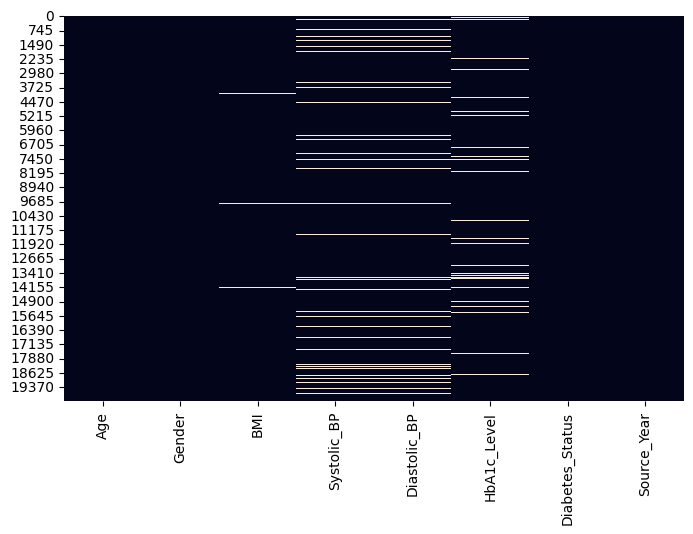

In [58]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [59]:
df.duplicated().sum()

np.int64(4)

In [60]:
df = df.drop_duplicates()

In [61]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*30)

Age
[69. 54. 72. 73. 56. 61. 65. 26. 76. 33. 16. 32. 18. 12. 38. 50. 23. 13.
 28. 14. 35. 29. 58. 57. 20. 37. 75. 43. 60. 55. 62. 36. 80. 31. 63. 71.
 67. 64. 46. 44. 19. 70. 59. 25. 39. 24. 30. 49. 45. 51. 77. 78. 66. 47.
 48. 53. 15. 17. 42. 21. 68. 52. 34. 40. 27. 41. 22. 79. 74.]
------------------------------
Gender
['Male' 'Female']
------------------------------
BMI
[26.7 28.6 28.9 19.7 41.7 35.7 26.5 22.  20.3 34.4 22.8 23.2 35.6 15.5
 35.9 23.6 18.6 25.3 30.1 38.7 26.2 31.  24.7 31.2 38.3 32.  31.8 17.8
 36.8 20.9 34.9 24.2 21.1 26.9 38.9 39.1 21.6 26.  24.  32.7 27.3 24.6
 26.3 28.3 36.5 20.4 31.7 30.5 24.8 30.3 22.1 19.3 37.8 25.8 29.2 27.7
 36.4 36.2 28.  30.4 46.1 21.  23.4 33.  35.1 29.1 32.3 34.8 21.3 27.
 21.5 37.6 33.7 18.  33.6 21.4 18.9 23.8 35.2 26.8 22.5 22.7 46.2 26.1
 30.8 32.2 25.9 30.9 26.4 34.6 32.5 40.9 33.4 19.2 25.1 21.2 44.5 27.5
 19.1 25.6 37.5 17.2 39.7 22.2 36.  19.  28.5 40.3 20.6 52.3 18.1 24.1
 30.2 24.9 29.7 28.2 29.9 64.7 54.2 23.  49.9 27.8 33.5 2

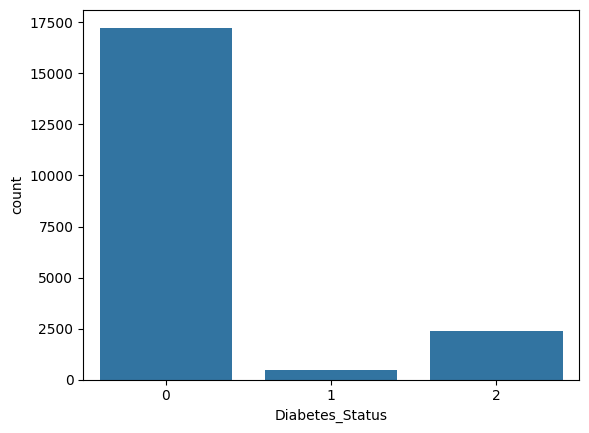

In [62]:
sns.countplot(x="Diabetes_Status", data=df)
plt.show()

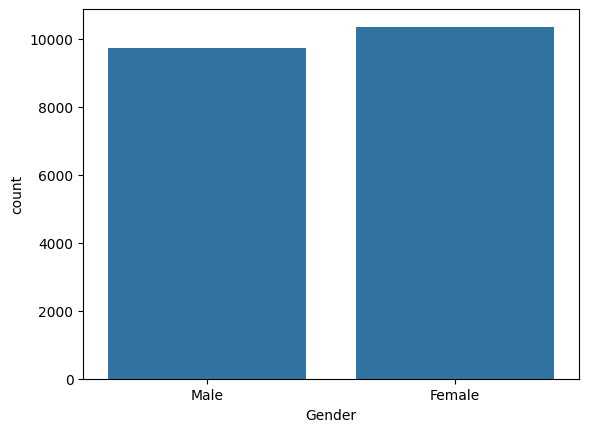

In [63]:
sns.countplot(x="Gender", data=df)
plt.show()

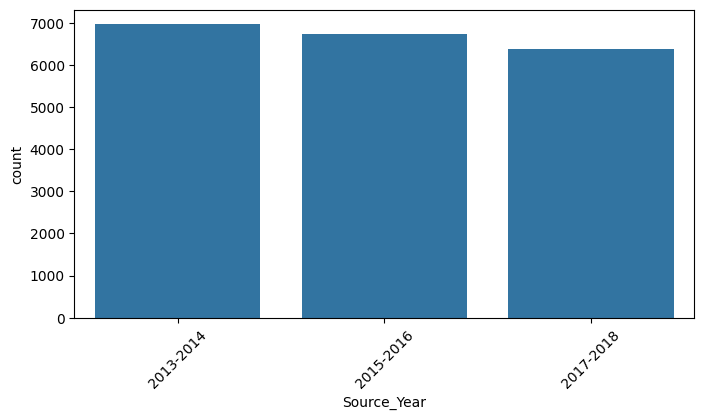

In [64]:
plt.figure(figsize=(8,4))
sns.countplot(x="Source_Year", data=df)
plt.xticks(rotation=45)
plt.show()

In [65]:
num_cols = df.select_dtypes(include=np.number).columns

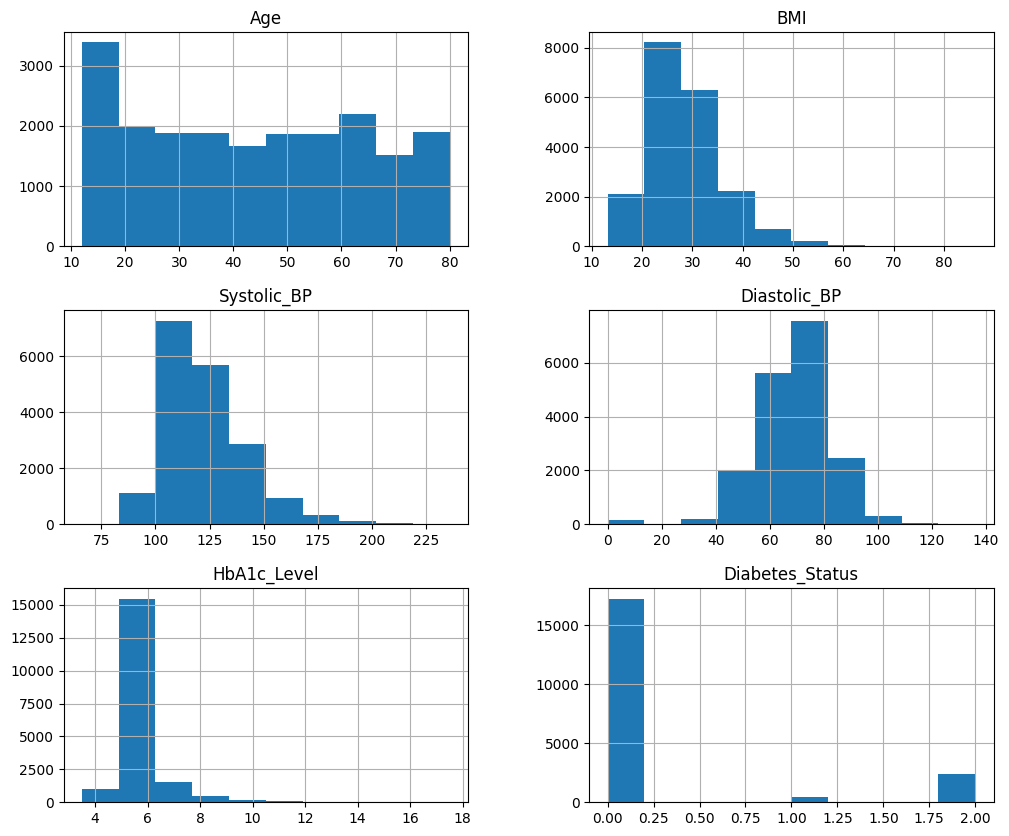

In [66]:
df[num_cols].hist(figsize=(12,10))
plt.show()

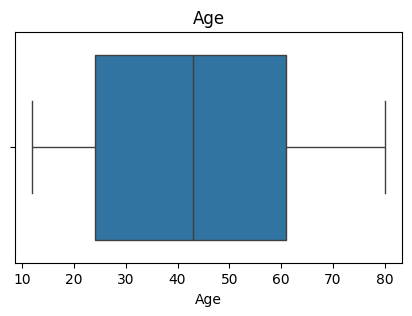

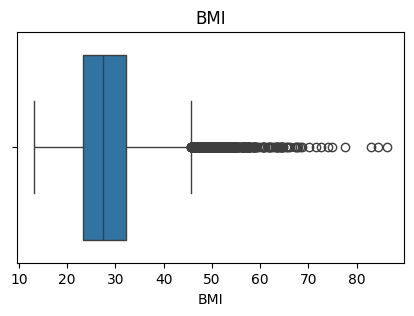

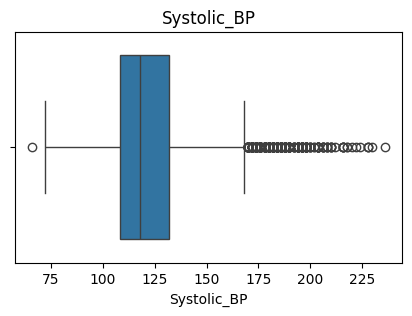

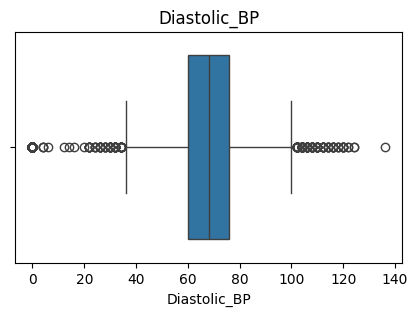

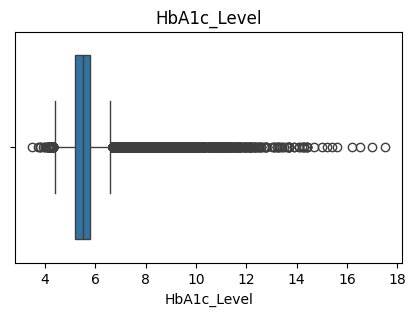

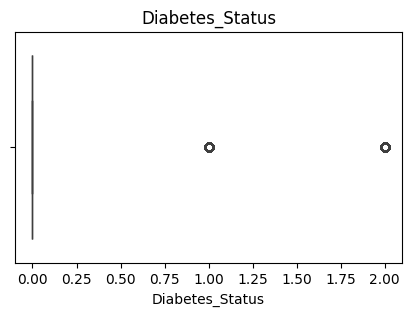

In [68]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

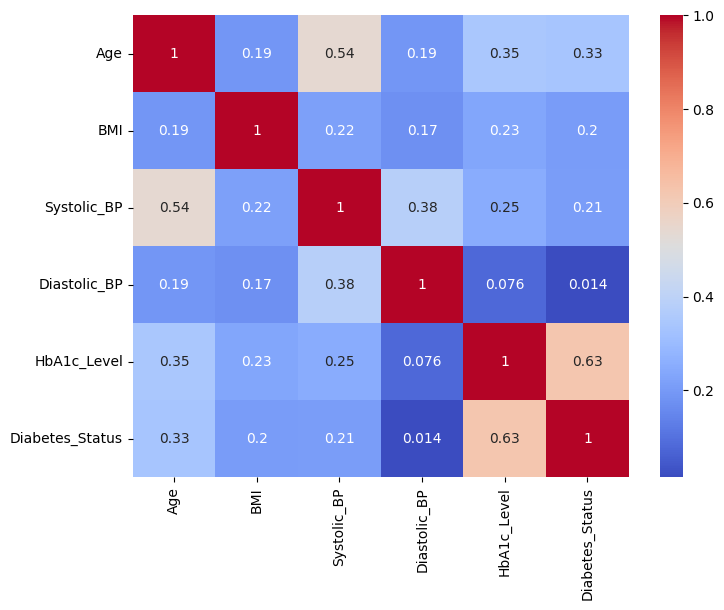

In [69]:
plt.figure(figsize=(8,6))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.show()


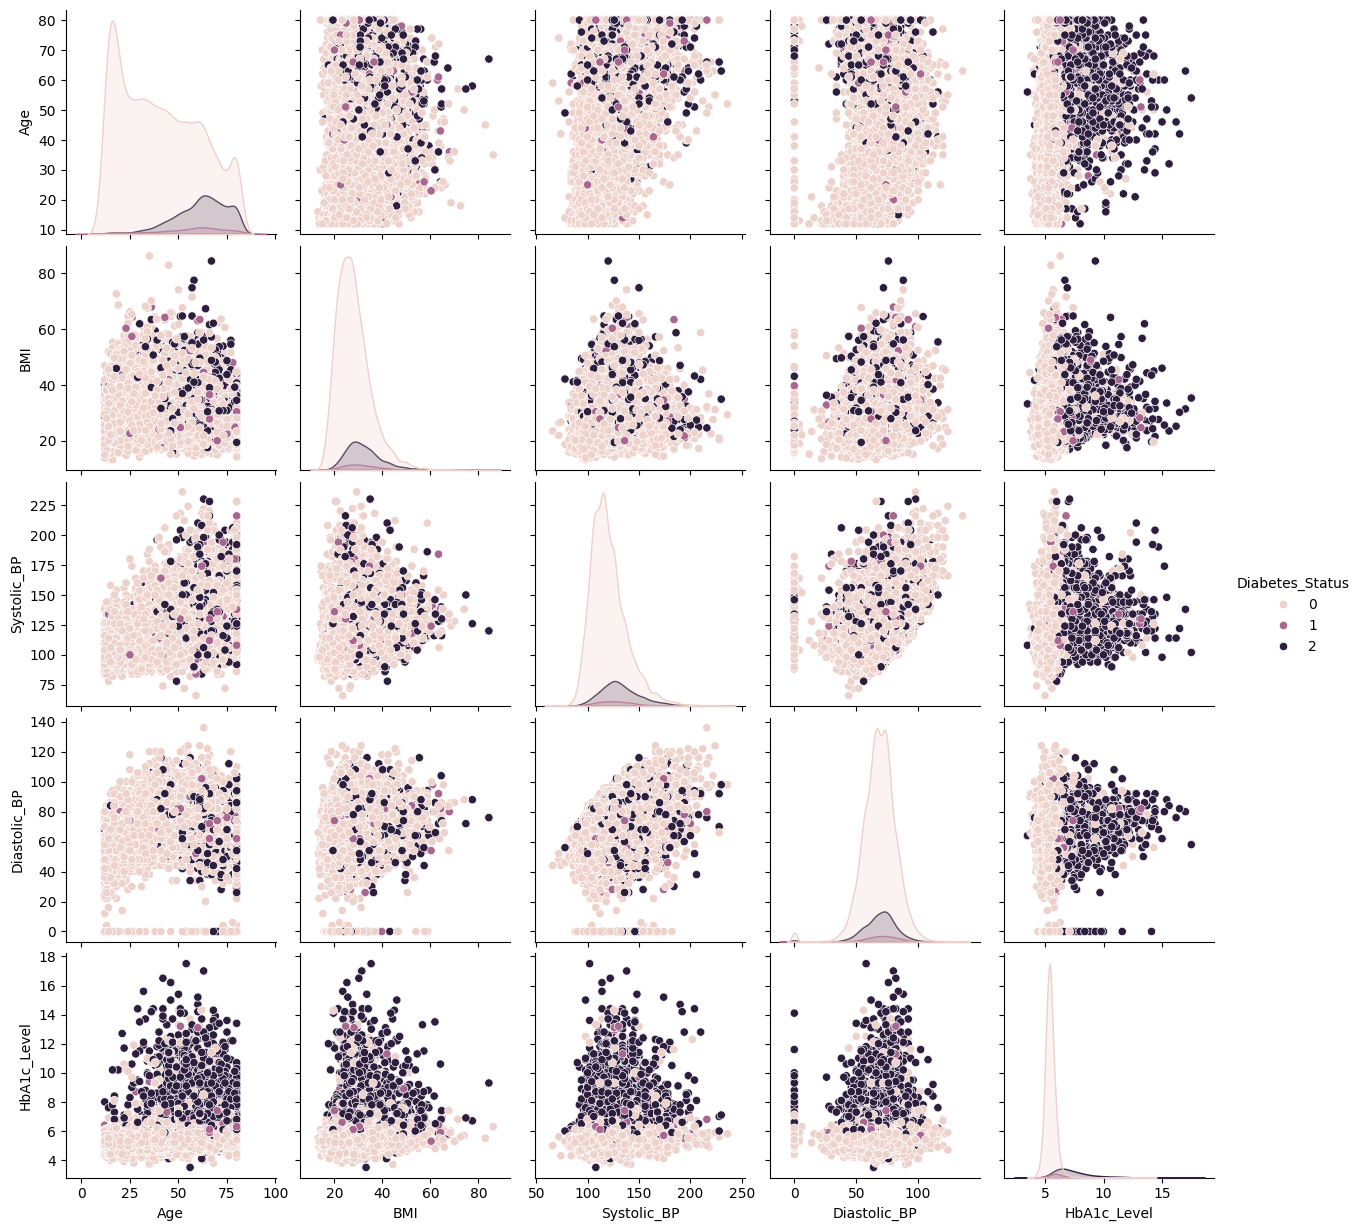

In [70]:
sns.pairplot(df,
             hue="Diabetes_Status")

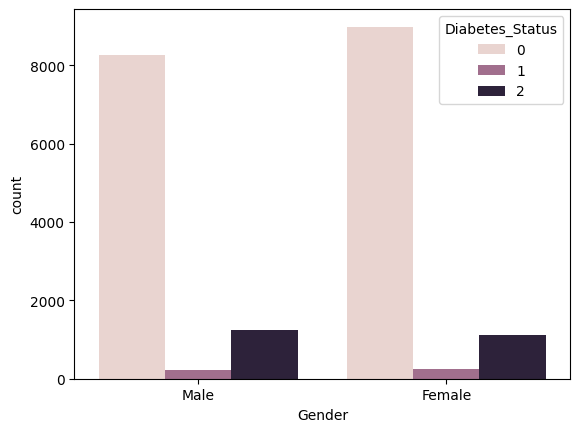

In [71]:
sns.countplot(x="Gender",
              hue="Diabetes_Status",
              data=df)
plt.show()

<Axes: xlabel='Diabetes_Status', ylabel='Age'>

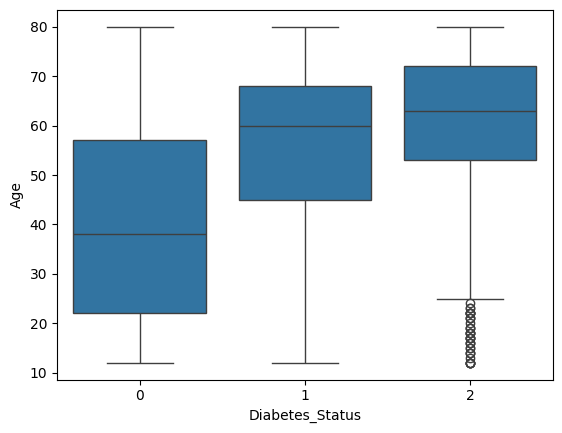

In [72]:
sns.boxplot(x="Diabetes_Status",
            y="Age",
            data=df)

<Axes: xlabel='Diabetes_Status', ylabel='BMI'>

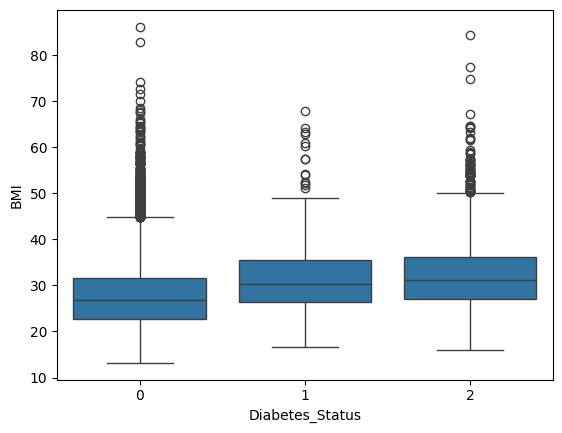

In [73]:
sns.boxplot(x="Diabetes_Status",
            y="BMI",
            data=df)

<Axes: xlabel='Diabetes_Status', ylabel='HbA1c_Level'>

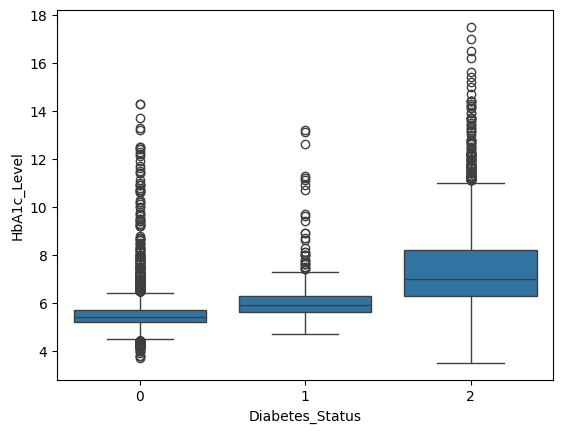

In [74]:
sns.boxplot(x="Diabetes_Status",
            y="HbA1c_Level",
            data=df)


<Axes: xlabel='Diabetes_Status', ylabel='Systolic_BP'>

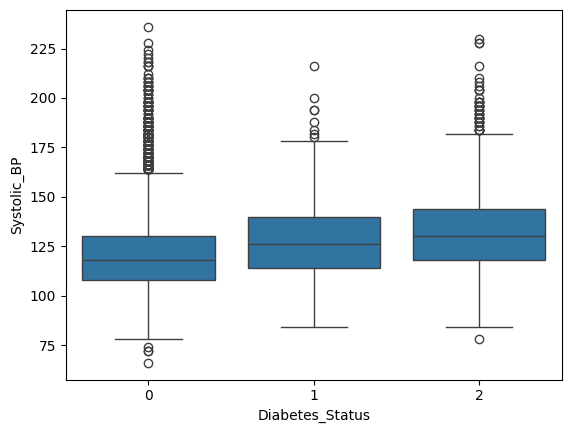

In [75]:
sns.boxplot(x="Diabetes_Status",
            y="Systolic_BP",
            data=df)

In [77]:
df["BMI"].fillna(df["BMI"].median(), inplace=True)

df["Systolic_BP"].fillna(df["Systolic_BP"].median(), inplace=True)

df["Diastolic_BP"].fillna(df["Diastolic_BP"].median(), inplace=True)

df["HbA1c_Level"].fillna(df["HbA1c_Level"].median(), inplace=True)

In [78]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [79]:
df = pd.get_dummies(df,
                    columns=["Source_Year"],
                    drop_first=True)

In [80]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Systolic_BP,0
Diastolic_BP,0
HbA1c_Level,0
Diabetes_Status,0
Source_Year_2015-2016,0
Source_Year_2017-2018,0


In [81]:
X = df.drop("Diabetes_Status", axis=1)

y = df["Diabetes_Status"]

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)